In [ ]:
#Data tools
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#Stats
from scipy import stats

# Data import

import kagglehub

# Saves graphs as vector graphics for better scalability
%config InlineBackend.figure_format = 'svg'

print('Done Importing')

Done Importing


In [ ]:
#ds_one_path = "C:/Users/blackhawkone/Downloads/Students_gamification_grades.csv"

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/lesson_2/Students_gamification_grades.csv')

print(f"Shape: {df.shape}")
df.head()

Mounted at /content/drive
Shape: (69, 16)


,Student_ID,Practice_Exam,Final_Exam,User,Avg_Grade_Q1,Avg_Grade_Q2,Avg_Grade_Q3,Avg_Grade_Q4,Avg_Grade_Q5,Avg_Grade_Q6,No_access_Q1,No_access_Q2,No_access_Q3,No_access_Q4,No_access_Q5,No_access_Q6
0,1046,9.33,7.98,1,6.00,10.0,10.0,10.0,0.0,8.0,1,1,1,1,0,1
1,1048,2.89,6.49,0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,1050,7.67,6.90,1,9.00,10.0,10.0,10.0,10.0,10.0,1,1,1,1,1,1
3,1052,4.97,7.69,1,6.00,9.0,5.0,4.0,9.0,4.0,2,2,2,1,1,2
4,1054,3.89,7.78,1,9.33,10.0,10.0,10.0,10.0,10.0,12,1,1,1,1,1


In [ ]:
# Cleanup

# remove people who didnt take the practice test (the only column with null values was the practice test column) and the people who put no effort on the quizzes (none)
df_nn = df[df['Practice_Exam'].notna() & df['Final_Exam'].notna() & ((df['No_access_Q1'] + df['No_access_Q2'] + df['No_access_Q3'] + df['No_access_Q4'] + df['No_access_Q5'] + df['No_access_Q6'] >= 3) | (df['User'] == 0))]

# remove unnecessary columns
df_clean = df_nn[['Practice_Exam','Final_Exam', 'User']]

#convert the user column into a boolean

def user_to_bool(response):
    if response == 1:
        return True
    else:
        return False

df_clean['bool_user'] = df_clean['User'].apply(user_to_bool)

df_clean['Improvement'] = df_clean['Final_Exam']-df_clean['Practice_Exam']

#groupby average

df_clean.groupby('bool_user')['Improvement'].mean()
df_clean[df_clean['bool_user'] == True].head(16)
# df_clean.groupby('bool_user').size() Gives 16 False (Not Gamified), 40 True (Gamified)

# plz fix the error regarding data_grouped not being defined if you want to use this code
# data_grouped_df = pd.DataFrame(data_grouped)

# mean_imp_true = data_grouped_df.at[True,'Improvement']
# mean_imp_false = data_grouped_df.at[False,'Improvement']
# mean_imp_diff = mean_imp_true - mean_imp_false

# print(f'The mean improvement for users vs non-users is {mean_imp_true:.4f} vs {mean_imp_false:.4f}')
# print(f'The difference in mean improvement between groups (users minus non-users) is {mean_imp_diff:.4f}')

/tmp/ipykernel_44609/3229439841.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bool_user'] = df_clean['User'].apply(user_to_bool)
/tmp/ipykernel_44609/3229439841.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Improvement'] = df_clean['Final_Exam']-df_clean['Practice_Exam']


,Practice_Exam,Final_Exam,User,bool_user,Improvement
0,9.33,7.98,1,True,-1.35
2,7.67,6.90,1,True,-0.77
3,4.97,7.69,1,True,2.72
4,3.89,7.78,1,True,3.89
5,4.75,6.02,1,True,1.27
9,5.57,7.64,1,True,2.07
11,8.43,6.25,1,True,-2.18
12,5.00,6.53,1,True,1.53
13,4.28,5.28,1,True,1.00
14,6.78,7.59,1,True,0.81


/tmp/ipykernel_18640/2738057453.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Treatment'] = df_clean['bool_user'].apply(conv_treat_readable)


Text(0.5, 1.0, 'Median improvement is roughly similar between treatment groups')

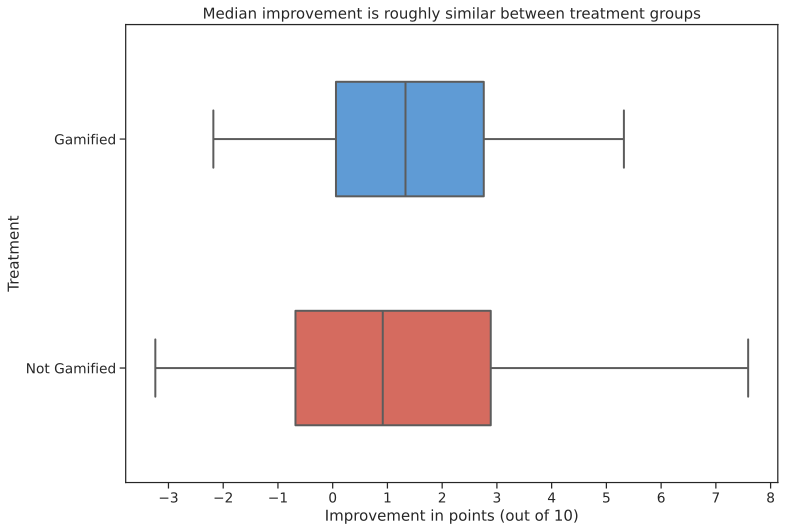

In [ ]:
# The mean improvement for users vs non-users is 1.60 vs 1.43.
# Test whether this is a significant improvement or not.

#add a column called "treatment" with Gamified and Not Gamified as labels

def conv_treat_readable(treatment):
    if treatment == True:
        return 'Gamified'
    else:
        return 'Not Gamified'

df_clean['Treatment'] = df_clean['bool_user'].apply(conv_treat_readable)

sns.set_theme(rc={'figure.figsize':(11.7,8.27)}) # sets default plot size
sns.set_style('ticks')
sns.set_context('notebook',font_scale=1.25)

ax = sns.boxplot(
    data=df_clean,
    x='Improvement',
    y='Treatment',
    hue = 'Treatment', # Assigns hue based on 'Treatment' column value
    width=0.5,
    linewidth=2,
    palette={'Gamified': '#4C9BE8', 'Not Gamified': '#E85C4C'},
)

loc = mpl.ticker.MultipleLocator(base=1.0) # this locator puts ticks at regular intervals. ticker is the tick library. MultipleLocator is the regular interval tick class.
ax.xaxis.set_major_locator(loc)

plt.xlabel('Improvement in points (out of 10)')
plt.title('Median improvement is roughly similar between treatment groups')

In [ ]:
# two sample t-test

result = stats.ttest_ind(
    df_clean.loc[df_clean['Treatment'] == 'Gamified', 'Improvement'], # Selects all values from the 'Improvement column' where treatment is Gamified.
    df_clean.loc[df_clean['Treatment'] == 'Not Gamified', 'Improvement'],
    equal_var=False,
    alternative='greater',
    method=None)

print(f'T-statistic = {result.statistic}')
print(f'P-Value = {result.pvalue}')

alpha = 0.05

if result.pvalue < alpha:
    print(f'p-value ({result.pvalue}) is less than alpha = {alpha}')
    print('The results are statistically significant, and cannot reasonably be attributed to random chance alone')
else:
    print(f'p-value ({result.pvalue}) is greater than alpha = {alpha}')
    print('The results are not statistically significant and can reasonably be attributed to random chance alone')

T-statistic = -0.21911704315220928
P-Value = 0.5856443665234639
p-value (0.5856443665234639) is greater than alpha = 0.05
The results are not statistically significant and can reasonably be attributed to random chance alone


-3.6312499999999996 2.565125
0.42554255425542553 is the p-value for the one-sided test
-1.8377499999999998 1.3412500000000005
is the 95% confidence interval


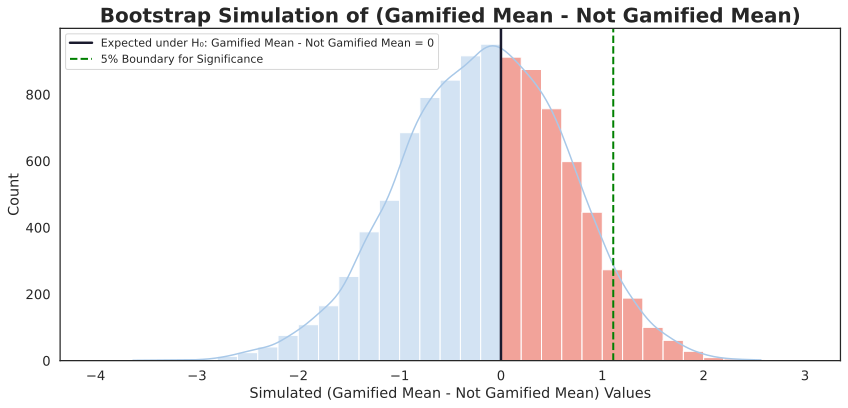

In [ ]:
#bootstrap simulation

from scipy.stats import bootstrap

def diff_mean(x, y):
    return np.mean(x) - np.mean(y)

result = stats.bootstrap((df_clean.loc[df_clean['Treatment'] == 'Gamified', 'Improvement'], df_clean.loc[df_clean['Treatment'] == 'Not Gamified', 'Improvement']), diff_mean, confidence_level=0.95)
values = result.bootstrap_distribution
values.sort()
print(values[0], values[9998]) # Warning: print doesn't work when you try to concatenate a float and a string

# Visualize the differences in means from each simulation trial
sns.set_theme(style='white', font_scale=1.2)
plt.rcParams['figure.figsize'] = (8, 5)
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

sns.histplot(values, bins=35, kde=True, color="#A8C8E8", ax = axes, binrange = [-4, 3])
for i in range(20, 35):
  axes.patches[i].set_facecolor("#F2A39A")
axes.set_title('Bootstrap Simulation of (Gamified Mean - Not Gamified Mean)', fontsize=20, fontweight='bold')
axes.set_xlabel('Simulated (Gamified Mean - Not Gamified Mean) Values')
axes.set_ylabel('Count')

# Mark the 0 column
axes.axvline(x=0, color='#1a1a2e', linestyle='-', linewidth=2.5, label=f'Expected under H₀: Gamified Mean - Not Gamified Mean = 0')
# Mark the ends of the confidence interval
axes.axvline(x=values[9499], color='green', linestyle='--', linewidth=2, label=f'5% Boundary for Significance')
# Create the legend (must go after the lines)
axes.legend(fontsize=11)

# Calculate p-value (first two lines are unnecessary)
# means = df_clean.groupby('bool_user')['Improvement'].mean()
# observed_diff = means[True] - means[False]
length = len(values)
good = 0
for simulated_diff in values:
    if simulated_diff >= 0:
        good += 1

print(str(good/length) + " is the p-value for the one-sided test")
print(values[249],values[9749])
print("is the 95% confidence interval")